In [52]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data.processed_data import get_featured_data
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.manifold import TSNE

In [53]:
data = get_featured_data()
data

,price,recommendations,Indie,Casual,Adventure,Action,Simulation,Strategy,RPG,Free To Play,Early Access,Sports,Racing,Single-player,Family Sharing,Steam Achievements,Steam Cloud,Full controller support,Multi-player,Partial Controller Support
appid,,,,,,,,,,,,,,,,,,,,
3057270,0.833055,0.5,1,0,1,1,0,1,1,0,0,0,0,1,1,0,0,0,0,0
3822840,0.899900,0.5,1,1,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0
3216640,0.933289,0.5,1,0,1,0,0,1,0,0,0,0,0,1,1,1,1,1,0,0
2403620,0.962949,0.5,1,0,1,1,0,0,0,0,0,0,0,1,1,1,1,1,0,0
1538040,0.833055,0.5,1,1,1,1,0,0,1,0,1,0,0,1,1,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3097010,0.941142,0.5,1,1,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0
3304930,0.856938,0.5,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0
1461580,0.941142,0.5,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0


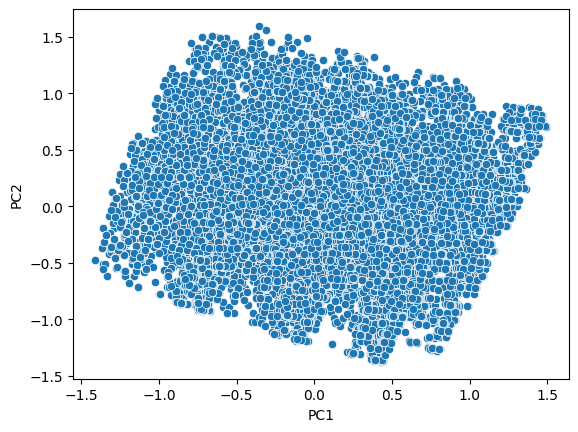

Varianza explicada por cada componente: [0.13457112 0.12379541]
Varianza total explicada por PC1+PC2: 0.25836653


In [54]:
# 1. Aplicas PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data)  
# 2. Lo conviertes a un DataFrame de Pandas (Buena práctica)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

# 3. Graficas usando el DataFrame
sns.scatterplot(data=pca_df, x='PC1', y='PC2')
plt.show()
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza total explicada por PC1+PC2:", pca.explained_variance_ratio_.sum())

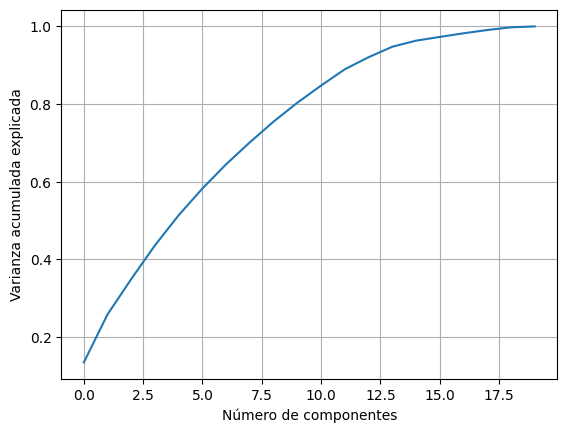

In [55]:
pca_full = PCA().fit(data)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.grid(True)
plt.show()

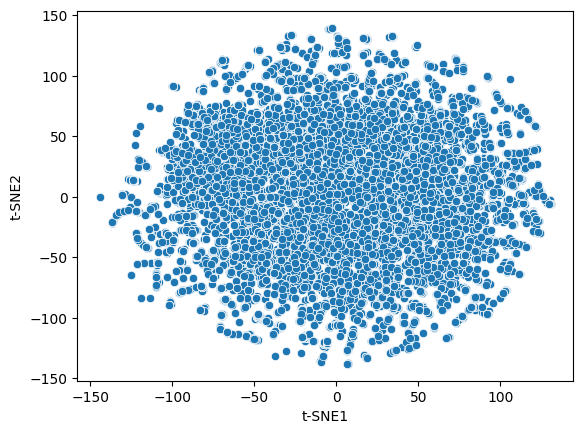

In [56]:
# apply  t-SNE
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
tsne_data = tsne.fit_transform(data)
tsne_df = pd.DataFrame(tsne_data, columns=['t-SNE1', 't-SNE2'])
sns.scatterplot(data=tsne_df, x='t-SNE1', y='t-SNE2')
plt.show()